In [ ]:
9import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from functools import reduce
import random

# 1. IMPORTING THE DATASET

In [ ]:
df = pd.read_csv("/content/FILTERED_MENTAL_HEALTH_DATASET.csv")
df

/tmp/ipython-input-834646190.py:1: DtypeWarning: Columns (8,9,10,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/FILTERED_MENTAL_HEALTH_DATASET.csv")


,COUNTRYNEW,FIELD_DATE,YEAR_WAVE,Knowledge_about_Science,Trust_in_science,Tech_Impact_Local_Jobs_5Yrs,Health_Impact_of_ScienceA,Science_Explain_Emotions,WHO_based_decisions,Doctors_Based_Decisions,...,SM_Usage_Freq,HealthContent_on_SM,Science_vs_Religion_Belief\n,Age,Gender,Education,Per_capita_income,wbi,Income_Satisfaction,Employment_Status
0,United States,10-01-2020,2020,2,3,2,Mostly positive,1,4,2,...,less,Some of the time,Religion,80.0,Female,Secondary,5,4.0,Getting by on present income,Unemployed
1,United States,10-01-2020,2020,1,1,1,Mostly positive,1,1,1,...,Several times a day,Some of the time,,23.0,Male,University,4,4.0,Living comfortably,Employed
2,United States,10-01-2020,2020,1,1,1,Mostly positive,1,1,1,...,Almost every hour,Most of the time,,29.0,Male,University,4,4.0,Living comfortably,Employed
3,United States,10-01-2020,2020,2,2,2,No impact,3,1,1,...,less,Never,Science,60.0,Female,University,4,4.0,Getting by on present income,Employed
4,United States,10-01-2020,2020,3,1,3,Mostly positive,3,1,1,...,Several times as hour,Some of the time,,41.0,Male,Secondary,2,4.0,Very difficult,Unemployed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48203,Vietnam,12-01-2020,2020,4,1,1,Mostly positive,1,1,1,...,,,Science,40.0,Female,University,5,2.0,Living comfortably,Part time Employed
48204,Vietnam,12-01-2020,2020,2,0,1,Mostly positive,1,0,1,...,Several times as hour,All of the time,99,30.0,Male,Secondary,3,2.0,Finding it difficult on present income,Out of workforce
48205,Vietnam,12-01-2020,2020,2,3,0,Mostly positive,1,3,1,...,Several times a day,Some of the time,Religion,47.0,Female,University,5,2.0,Living comfortably,Self Employed
48206,Vietnam,12-01-2020,2020,2,3,1,Mostly positive,1,1,1,...,Several times a day,Most of the time,,24.0,Male,University,2,2.0,Living comfortably,Self Employed


In [ ]:
df.shape

(48208, 33)

#PROBLEM STATEMENT

#####To analyze the impact of demographic, scientific trust, and socio-economic factors on an individual's self-reported mental health status, and to build a machine learning model that predicts whether a person is likely to experience mental health issues.

# 2. UNDERSTAND THE DATASET

In [ ]:
df.head()

,COUNTRYNEW,FIELD_DATE,YEAR_WAVE,Knowledge_about_Science,Trust_in_science,Tech_Impact_Local_Jobs_5Yrs,Health_Impact_of_ScienceA,Science_Explain_Emotions,WHO_based_decisions,Doctors_Based_Decisions,...,SM_Usage_Freq,HealthContent_on_SM,Science_vs_Religion_Belief\n,Age,Gender,Education,Per_capita_income,wbi,Income_Satisfaction,Employment_Status
0,United States,10-01-2020,2020,2,3,2,Mostly positive,1,4,2,...,less,Some of the time,Religion,80.0,Female,Secondary,5,4.0,Getting by on present income,Unemployed
1,United States,10-01-2020,2020,1,1,1,Mostly positive,1,1,1,...,Several times a day,Some of the time,,23.0,Male,University,4,4.0,Living comfortably,Employed
2,United States,10-01-2020,2020,1,1,1,Mostly positive,1,1,1,...,Almost every hour,Most of the time,,29.0,Male,University,4,4.0,Living comfortably,Employed
3,United States,10-01-2020,2020,2,2,2,No impact,3,1,1,...,less,Never,Science,60.0,Female,University,4,4.0,Getting by on present income,Employed
4,United States,10-01-2020,2020,3,1,3,Mostly positive,3,1,1,...,Several times as hour,Some of the time,,41.0,Male,Secondary,2,4.0,Very difficult,Unemployed


In [ ]:
df.tail()

,COUNTRYNEW,FIELD_DATE,YEAR_WAVE,Knowledge_about_Science,Trust_in_science,Tech_Impact_Local_Jobs_5Yrs,Health_Impact_of_ScienceA,Science_Explain_Emotions,WHO_based_decisions,Doctors_Based_Decisions,...,SM_Usage_Freq,HealthContent_on_SM,Science_vs_Religion_Belief\n,Age,Gender,Education,Per_capita_income,wbi,Income_Satisfaction,Employment_Status
48203,Vietnam,12-01-2020,2020,4,1,1,Mostly positive,1,1,1,...,,,Science,40.0,Female,University,5,2.0,Living comfortably,Part time Employed
48204,Vietnam,12-01-2020,2020,2,0,1,Mostly positive,1,0,1,...,Several times as hour,All of the time,99,30.0,Male,Secondary,3,2.0,Finding it difficult on present income,Out of workforce
48205,Vietnam,12-01-2020,2020,2,3,0,Mostly positive,1,3,1,...,Several times a day,Some of the time,Religion,47.0,Female,University,5,2.0,Living comfortably,Self Employed
48206,Vietnam,12-01-2020,2020,2,3,1,Mostly positive,1,1,1,...,Several times a day,Most of the time,,24.0,Male,University,2,2.0,Living comfortably,Self Employed
48207,Vietnam,12-01-2020,2020,2,2,1,Mostly positive,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.describe()

,YEAR_WAVE,Knowledge_about_Science,Trust_in_science,Tech_Impact_Local_Jobs_5Yrs,Science_Explain_Emotions,Science_Helps_Treat_AnxDep,Friends_Family_MH_Issues,Self_MH_Status,Used_Social_Media,Age,wbi
count,48208.0,48208.000000,48208.00000,48208.000000,48208.000000,48208.000000,48207.000000,48207.000000,48207.000000,48207.000000,48207.000000
mean,2020.0,2.339321,1.57758,1.346768,1.701315,1.858177,1.562740,3.144668,1.510196,41.336072,3.115751
std,0.0,0.862210,0.82325,0.723901,1.044215,0.939842,0.551651,11.335023,5.425386,18.174420,0.888625
min,2020.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,15.000000,1.000000
25%,2020.0,2.000000,1.00000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,27.000000,2.000000
50%,2020.0,2.000000,1.00000,1.000000,1.000000,2.000000,2.000000,2.000000,1.000000,37.000000,3.000000
75%,2020.0,3.000000,2.00000,2.000000,3.000000,2.000000,2.000000,2.000000,1.000000,54.000000,4.000000
max,2020.0,4.000000,4.00000,3.000000,4.000000,4.000000,2.000000,99.000000,99.000000,100.000000,4.000000


In [ ]:
df.shape

(48208, 33)

In [ ]:
#Getting top 15 countries
unique_countries = df['COUNTRYNEW'].dropna().unique()
unique_countries
df['COUNTRYNEW'].value_counts().head(15)


,count
COUNTRYNEW,
China,3502
India,3045
Russia,2002
Israel,1063
Lebanon,1035
Montenegro,1027
Uganda,1027
Senegal,1025
Indonesia,1023


In [ ]:
#Creating another dataframe of top 15 countries
df1 = df[df['COUNTRYNEW'].isin(['China', 'India', 'Russia', 'Israel', 'Lebanon','Uganda','Montenegro','Senegal','Indonesia','Chile','Algeria','North Macedonia','Estonia','Saudi Arabia','Cyprus'])]
df1

,COUNTRYNEW,FIELD_DATE,YEAR_WAVE,Knowledge_about_Science,Trust_in_science,Tech_Impact_Local_Jobs_5Yrs,Health_Impact_of_ScienceA,Science_Explain_Emotions,WHO_based_decisions,Doctors_Based_Decisions,...,SM_Usage_Freq,HealthContent_on_SM,Science_vs_Religion_Belief\n,Age,Gender,Education,Per_capita_income,wbi,Income_Satisfaction,Employment_Status
3017,Lebanon,12-01-2020,2020,2,2,2,Mostly positive,2,1,1,...,Once a day,Some of the time,Science,62,Female,University,5,3,Finding it difficult on present income,Unemployed
3018,Lebanon,12-01-2020,2020,3,3,2,Mostly positive,4,3,3,...,,,Religion,44,Male,Secondary,2,3,Finding it difficult on present income,Unemployed
3019,Lebanon,12-01-2020,2020,2,3,2,99,0,1,2,...,Several times a day,Some of the time,Religion,38,Female,University,5,3,Getting by on present income,Unemployed
3020,Lebanon,12-01-2020,2020,0,0,2,99,0,1,2,...,less,Never,Religion,62,Male,Primary,3,3,Finding it difficult on present income,Unemployed
3021,Lebanon,12-01-2020,2020,2,1,2,Both,2,1,1,...,Almost every hour,Some of the time,Science,25,Male,University,5,3,Getting by on present income,Out of workforce
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102051,Montenegro,12-01-2020,2020,1,3,0,Mostly positive,1,3,3,...,Several times a day,All of the time,Religion,32,Female,Primary,1,3,Living comfortably,Unemployed
102052,Montenegro,12-01-2020,2020,3,1,2,99,3,4,1,...,,,Religion,67,Male,Secondary,1,3,Finding it difficult on present income,Unemployed
102053,Montenegro,12-01-2020,2020,2,2,2,Mostly positive,1,2,1,...,Once a day,Some of the time,Science,27,Female,University,4,3,Living comfortably,Employed
102054,Montenegro,12-01-2020,2020,2,2,1,Mostly positive,1,1,1,...,Several times a day,Most of the time,Science,38,Female,Secondary,1,3,Getting by on present income,Unemployed


In [ ]:
countries = ['China', 'India', 'Russia', 'Israel', 'Lebanon', 'Uganda', 'Montenegro',
             'Senegal', 'Indonesia', 'Chile', 'Algeria', 'North Macedonia', 'Estonia',
             'Saudi Arabia', 'Cyprus']

df = pd.DataFrame({'COUNTRYNEW': countries, 'value': [1]*len(countries)})

fig = px.choropleth(
    df,
    locations='COUNTRYNEW',
    locationmode='country names',
    color='value',  # All same color
    hover_name='COUNTRYNEW',
    color_continuous_scale=[[0, 'lightblue'], [1, 'blue']],
    title='Selected Countries Highlighted on World Map'
)

fig.update_coloraxes(showscale=False)
fig.show()


# 3. VIEWING DATASET STRUCTURE






In [ ]:
df1.shape

(20847, 33)

In [ ]:
df1.columns

Index(['COUNTRYNEW', 'FIELD_DATE', 'YEAR_WAVE', 'Knowledge_about_Science',
       'Trust_in_science', 'Tech_Impact_Local_Jobs_5Yrs',
       'Health_Impact_of_ScienceA', 'Science_Explain_Emotions',
       'WHO_based_decisions', 'Doctors_Based_Decisions',
       'Religion_Sci_Based_Decisions', 'Importance of Mental Health ',
       'Science_Helps_Treat_AnxDep', 'Gov_Fund_MH_Research',
       'Communication_about_MH', 'Friends_Family_MH_Issues', 'Self_MH_Status',
       'Age_First_AnxDep', 'Repeated_Experience', 'Talked_MH_Professional',
       'Helpfulness_MH_Professional\n', 'Medication_helpfullness',
       'Used_Social_Media', 'SM_Usage_Freq', 'HealthContent_on_SM',
       'Science_vs_Religion_Belief\n', 'Age', 'Gender', 'Education',
       'Per_capita_income', 'wbi', 'Income_Satisfaction', 'Employment_Status'],
      dtype='object')

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20847 entries, 3017 to 102055
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   COUNTRYNEW                    20847 non-null  object
 1   FIELD_DATE                    20847 non-null  object
 2   YEAR_WAVE                     20847 non-null  int64 
 3   Knowledge_about_Science       20847 non-null  int64 
 4   Trust_in_science              20847 non-null  int64 
 5   Tech_Impact_Local_Jobs_5Yrs   20847 non-null  int64 
 6   Health_Impact_of_ScienceA     20847 non-null  object
 7   Science_Explain_Emotions      20847 non-null  int64 
 8   WHO_based_decisions           20847 non-null  object
 9   Doctors_Based_Decisions       20847 non-null  object
 10  Religion_Sci_Based_Decisions  20847 non-null  object
 11  Importance of Mental Health   20847 non-null  object
 12  Science_Helps_Treat_AnxDep    20847 non-null  object
 13  Gov_Fund_MH_Resea

# Summary statistics

In [ ]:
# Step 1: Remove spaces and convert to numeric
df1['Age_First_AnxDep'] = pd.to_numeric(df1['Age_First_AnxDep'].astype(str).str.strip(), errors='coerce')

# Step 2: Drop NaNs caused by non-numeric entries
df1 = df1.dropna(subset=['Age_First_AnxDep'])

# Step 3: Calculate the mean
mean_age = df1['Age_First_AnxDep'].mean()
print("Mean age of first anxiety/depression:", mean_age)


Mean age of first anxiety/depression: 31.33041814703471


/tmp/ipython-input-1963668866.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
df1['Age_First_AnxDep'].mean()

np.float64(31.33041814703471)

In [ ]:
df1.describe()

,YEAR_WAVE,Knowledge_about_Science,Trust_in_science,Tech_Impact_Local_Jobs_5Yrs,Science_Explain_Emotions,Friends_Family_MH_Issues,Age_First_AnxDep,Used_Social_Media,Age,wbi
count,3659.0,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000,3659.000000
mean,2020.0,2.330965,1.625307,1.414048,1.784094,1.251435,31.330418,1.487018,36.459142,2.959278
std,0.0,0.882706,0.878841,0.715699,1.026366,0.473658,21.355715,5.606617,15.241366,0.860552
min,2020.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,15.000000,1.000000
25%,2020.0,2.000000,1.000000,1.000000,1.000000,1.000000,18.000000,1.000000,25.000000,2.000000
50%,2020.0,2.000000,2.000000,1.000000,1.000000,1.000000,25.000000,1.000000,33.000000,3.000000
75%,2020.0,3.000000,2.000000,2.000000,3.000000,2.000000,36.000000,1.000000,45.000000,4.000000
max,2020.0,4.000000,4.000000,3.000000,4.000000,2.000000,99.000000,99.000000,100.000000,4.000000


# 4. CLEANING THE DATASET

In [ ]:
#Finding out the count of duplicate values in the dataset
df1.duplicated().sum()

np.int64(7)

In [ ]:
#Finding out duplicated rows
df1.duplicated()

,0
3022,False
3027,False
3030,False
3043,False
3059,False
...,...
102026,False
102037,False
102047,False
102052,False


In [ ]:
#Droping duplicated rows
df1.drop_duplicates()


,COUNTRYNEW,FIELD_DATE,YEAR_WAVE,Knowledge_about_Science,Trust_in_science,Tech_Impact_Local_Jobs_5Yrs,Health_Impact_of_ScienceA,Science_Explain_Emotions,WHO_based_decisions,Doctors_Based_Decisions,...,SM_Usage_Freq,HealthContent_on_SM,Science_vs_Religion_Belief\n,Age,Gender,Education,Per_capita_income,wbi,Income_Satisfaction,Employment_Status
3022,Lebanon,12-01-2020,2020,2,2,1,Mostly positive,1,1,1,...,Almost every hour,Some of the time,Religion,37,Male,Secondary,2,3,Very difficult,Employed
3027,Lebanon,12-01-2020,2020,4,1,1,No impact,3,1,1,...,Several times as hour,Some of the time,Religion,51,Male,Secondary,1,3,Very difficult,Unemployed
3030,Lebanon,12-01-2020,2020,1,1,1,Mostly positive,2,2,2,...,Once a day,Most of the time,99,21,Male,Secondary,2,3,Finding it difficult on present income,Unemployed
3043,Lebanon,12-01-2020,2020,2,1,2,Both,2,1,1,...,,,Religion,66,Female,Secondary,2,3,Finding it difficult on present income,Unemployed
3059,Lebanon,12-01-2020,2020,3,1,1,No impact,3,1,1,...,Several times a day,Never,Religion,36,Male,Primary,2,3,Very difficult,Employed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102026,Montenegro,12-01-2020,2020,3,3,3,No impact,3,2,2,...,Several times a day,Some of the time,Religion,27,Male,Secondary,5,3,Living comfortably,Employed
102037,Montenegro,12-01-2020,2020,1,2,3,No impact,1,3,2,...,Several times as hour,Some of the time,,23,Female,Secondary,3,3,Living comfortably,Unemployed
102047,Montenegro,12-01-2020,2020,3,3,1,99,0,2,1,...,,,Science,60,Female,Secondary,4,3,Living comfortably,Employed
102052,Montenegro,12-01-2020,2020,3,1,2,99,3,4,1,...,,,Religion,67,Male,Secondary,1,3,Finding it difficult on present income,Unemployed


#5. MISSING VALUE ANALYSIS


In [ ]:
df1.isna().sum().sum()

np.int64(0)

In [ ]:
df1.isna().sum()

,0
COUNTRYNEW,0
FIELD_DATE,0
YEAR_WAVE,0
Knowledge_about_Science,0
Trust_in_science,0
Tech_Impact_Local_Jobs_5Yrs,0
Health_Impact_of_ScienceA,0
Science_Explain_Emotions,0
WHO_based_decisions,0
Doctors_Based_Decisions,0


#6. EXPLORING CATAGORICAL VALUES

In [ ]:
df1.dtypes


,0
COUNTRYNEW,object
FIELD_DATE,object
YEAR_WAVE,int64
Knowledge_about_Science,int64
Trust_in_science,int64
Tech_Impact_Local_Jobs_5Yrs,int64
Health_Impact_of_ScienceA,object
Science_Explain_Emotions,int64
WHO_based_decisions,object
Doctors_Based_Decisions,object


In [ ]:
print(df1['Gender'].value_counts())
print(df1['COUNTRYNEW'].value_counts())


Gender
Male      1908
Female    1751
Name: count, dtype: int64
COUNTRYNEW
India              745
Russia             513
Chile              364
Saudi Arabia       295
China              267
Cyprus             218
Senegal            206
Estonia            194
Lebanon            186
North Macedonia    158
Indonesia          144
Uganda             134
Algeria             79
Israel              78
Montenegro          78
Name: count, dtype: int64


In [ ]:
print(df1.Gender.value_counts())

Gender
Male      1908
Female    1751
Name: count, dtype: int64


In [ ]:
print(df1.COUNTRYNEW.value_counts())

COUNTRYNEW
India              745
Russia             513
Chile              364
Saudi Arabia       295
China              267
Cyprus             218
Senegal            206
Estonia            194
Lebanon            186
North Macedonia    158
Indonesia          144
Uganda             134
Algeria             79
Israel              78
Montenegro          78
Name: count, dtype: int64


In [ ]:
print(df1.Education.value_counts())

Education
Secondary     1909
University    1106
Primary        618
none            26
Name: count, dtype: int64


In [ ]:
print(df1.Employment_Status.value_counts())

Employment_Status
Employed              1340
Unemployed            1292
Self Employed          405
Out of workforce       401
Part time Employed     221
Name: count, dtype: int64


In [ ]:
print(df1.Health_Impact_of_ScienceA.value_counts())

Health_Impact_of_ScienceA
Mostly positive    2073
No impact           896
Mostly negative     414
Both                162
99                  114
Name: count, dtype: int64


# EXTRA

In [ ]:
df1 = df1.copy()

In [ ]:
df1['Health_Impact_of_ScienceA'] = df1['Health_Impact_of_ScienceA'].astype(str).replace('99', "Don't know")


In [ ]:
print(df1.Health_Impact_of_ScienceA.value_counts())

Health_Impact_of_ScienceA
Mostly positive    2073
No impact           896
Mostly negative     414
Both                162
Don't know          114
Name: count, dtype: int64


In [ ]:
df1.columns = df1.columns.str.strip() #by strip = removal of white spaces
df1.rename(columns={'Importance of Mental Health': 'Mental_Health_Importance'}, inplace=True)
df1.columns

Index(['COUNTRYNEW', 'FIELD_DATE', 'YEAR_WAVE', 'Knowledge_about_Science',
       'Trust_in_science', 'Tech_Impact_Local_Jobs_5Yrs',
       'Health_Impact_of_ScienceA', 'Science_Explain_Emotions',
       'WHO_based_decisions', 'Doctors_Based_Decisions',
       'Religion_Sci_Based_Decisions', 'Mental_Health_Importance',
       'Science_Helps_Treat_AnxDep', 'Gov_Fund_MH_Research',
       'Communication_about_MH', 'Friends_Family_MH_Issues', 'Self_MH_Status',
       'Age_First_AnxDep', 'Repeated_Experience', 'Talked_MH_Professional',
       'Helpfulness_MH_Professional', 'Medication_helpfullness',
       'Used_Social_Media', 'SM_Usage_Freq', 'HealthContent_on_SM',
       'Science_vs_Religion_Belief', 'Age', 'Gender', 'Education',
       'Per_capita_income', 'wbi', 'Income_Satisfaction', 'Employment_Status'],
      dtype='object')

In [ ]:
print(df1['Mental_Health_Importance'].value_counts())

Mental_Health_Importance
More important    1967
As important      1520
Less important     142
99                  30
Name: count, dtype: int64


In [ ]:
df1['Mental_Health_Importance'] = df1['Mental_Health_Importance'].astype(str).replace('99', "Don't know")
print(df1['Mental_Health_Importance'].value_counts())

Mental_Health_Importance
More important    1967
As important      1520
Less important     142
Don't know          30
Name: count, dtype: int64


In [ ]:
df1.Gov_Fund_MH_Research.value_counts()

,count
Gov_Fund_MH_Research,
Extremely important,2080
Somewhat important,835
,295
Not too important,230
Not important at all,159
Refused,60


In [ ]:
df1['Gov_Fund_MH_Research'] = df1['Gov_Fund_MH_Research'].astype(str).replace(' ', "Refused")
df1.Gov_Fund_MH_Research.value_counts()

,count
Gov_Fund_MH_Research,
Extremely important,2080
Somewhat important,835
Refused,355
Not too important,230
Not important at all,159


In [ ]:
df1.Communication_about_MH.value_counts()

,count
Communication_about_MH,
Somewhat comfortable,1318
Very comfortable,1153
Not at all comfortable,1038
99,150


In [ ]:
df1['Communication_about_MH'] = df1['Communication_about_MH'].astype(str).replace( '99', "Don't know")
df1.Communication_about_MH.value_counts()

,count
Communication_about_MH,
Somewhat comfortable,1318
Very comfortable,1153
Not at all comfortable,1038
Don't know,150


In [ ]:
df1[df1.applymap(lambda x: isinstance(x, str) and x.strip() == '')]
(df1 == ' ').sum()
(df1 == '').sum()



/tmp/ipython-input-1465326737.py:1: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,0
COUNTRYNEW,0
FIELD_DATE,0
YEAR_WAVE,0
Knowledge_about_Science,0
Trust_in_science,0
Tech_Impact_Local_Jobs_5Yrs,0
Health_Impact_of_ScienceA,0
Science_Explain_Emotions,0
WHO_based_decisions,0
Doctors_Based_Decisions,0


In [ ]:
df1['Self_MH_Status'] = df1['Self_MH_Status'].astype(int).replace( 99, 0)
df1.Self_MH_Status.value_counts()

,count
Self_MH_Status,
1,3659


In [ ]:
df1['SM_Usage_Freq'] = df1['SM_Usage_Freq'].replace([" ", "99", 99], "Don't know")
df1.SM_Usage_Freq.value_counts()

,count
SM_Usage_Freq,
Several times a day,1218
Several times as hour,677
Don't know,638
Almost every hour,407
Once a day,377
less,172
Once a week,170


In [ ]:
df1['HealthContent_on_SM'] = df1['HealthContent_on_SM'].replace([" ", "99", 99], "Don't know")
df1.HealthContent_on_SM.value_counts()

,count
HealthContent_on_SM,
Some of the time,1639
Don't know,639
Most of the time,601
All of the time,392
Never,388


In [ ]:
df1['Science_vs_Religion_Belief'] = df1['Science_vs_Religion_Belief'].replace([" ", "99", 99], "Don't know")
df1.Science_vs_Religion_Belief.value_counts()

,count
Science_vs_Religion_Belief,
Religion,1421
Science,1196
Don't know,1042


# 7. EXPLORING NUMERICAL VALUES

In [ ]:
df1['Age_First_AnxDep'].isna()

,Age_First_AnxDep
3022,False
3027,False
3030,False
3043,False
3059,False
...,...
102026,False
102037,False
102047,False
102052,False


In [ ]:

df1['Age_First_AnxDep'] = df1['Age_First_AnxDep'].astype(str).replace( " ", 20)
df1['Age_First_AnxDep'] = pd.to_numeric(df1['Age_First_AnxDep'], errors='coerce')

df1.Age_First_AnxDep.value_counts()

,count
Age_First_AnxDep,
20.0,271
99.0,225
18.0,209
25.0,207
15.0,194
...,...
76.0,1
72.0,1
73.0,1


In [ ]:
df1['Doctors_Based_Decisions'].value_counts()

,count
Doctors_Based_Decisions,
1,1468
2,714
1,553
,267
3,261
2,132
4,114
0,90
4,31


In [ ]:
df1['Doctors_Based_Decisions'] = df1['Doctors_Based_Decisions'].replace(" ", 0)
df1['Doctors_Based_Decisions'] = pd.to_numeric(df1['Doctors_Based_Decisions'], errors='coerce')
df1['Doctors_Based_Decisions'].value_counts()

,count
Doctors_Based_Decisions,
1,2021
2,846
0,365
3,282
4,145


In [ ]:
df1['Religion_Sci_Based_Decisions'].value_counts()

,count
Religion_Sci_Based_Decisions,
,562
2,511
4,454
3,424
1,386
1,349
2,336
4,267
0,169


In [ ]:
df1['Religion_Sci_Based_Decisions'] = pd.to_numeric(df1['Religion_Sci_Based_Decisions'], errors='coerce')
df1['Religion_Sci_Based_Decisions'].value_counts()

,count
Religion_Sci_Based_Decisions,
2.0,847
1.0,735
4.0,721
3.0,553
0.0,241


In [ ]:
df1['Repeated_Experience'] = pd.to_numeric(df1['Repeated_Experience'], errors='coerce')

df1['Repeated_Experience'] = df1['Repeated_Experience'].replace(99, 0)
df1.Repeated_Experience.value_counts()

,count
Repeated_Experience,
1,2503
2,1123
0,33


In [ ]:
df1.Talked_MH_Professional.value_counts()

,count
Talked_MH_Professional,
2,2085
1,1548
0,26


In [ ]:
df1['Talked_MH_Professional'] = df1['Talked_MH_Professional'].replace(" ", 0)
df1['Talked_MH_Professional'] = pd.to_numeric(df1['Talked_MH_Professional'], errors='coerce')

df1.Talked_MH_Professional.value_counts()

,count
Talked_MH_Professional,
2,2085
1,1548
0,26


In [ ]:
df1['Helpfulness_MH_Professional'] = df1['Helpfulness_MH_Professional'].replace(" ", 0)
df1['Helpfulness_MH_Professional'] = pd.to_numeric(df1['Helpfulness_MH_Professional'], errors='coerce')

df1.Helpfulness_MH_Professional.value_counts()

,count
Helpfulness_MH_Professional,
0,2132
1,940
2,453
3,134


In [ ]:
df1['Medication_helpfullness'] = df1['Medication_helpfullness'].replace(" ", 0)
df1['Medication_helpfullness'] = pd.to_numeric(df1['Medication_helpfullness'], errors='coerce')
df1.Medication_helpfullness.value_counts()

,count
Medication_helpfullness,
0,2078
1,868
2,546
3,167


In [ ]:
df1['Used_Social_Media'] = df1['Used_Social_Media'].replace(99, 0)
df1.Used_Social_Media.value_counts()

,count
Used_Social_Media,
1,3041
2,606
0,12


In [ ]:
df1['Per_capita_income'] = pd.to_numeric(df1['Per_capita_income'], errors='coerce')
df1.Per_capita_income.value_counts()

,count
Per_capita_income,
5,903
1,715
4,697
3,689
2,655


#Maximum and Minimum age when a person first felt anx/dep Globally


In [ ]:
#maximum and minimum age when a person first felt anx/dep Globally
print("Max age when first experienced anxiety or depression:", df1['Age_First_AnxDep'].max())
print("Min age when first experienced anxiety or depression:", df1['Age_First_AnxDep'].min())

Max age when first experienced anxiety or depression: 99.0
Min age when first experienced anxiety or depression: 1.0


# Maximum and Minimum age when a person first felt anx/dep per country

In [ ]:
age_stats = df1.groupby('COUNTRYNEW')['Age_First_AnxDep'].agg(['min', 'max']).reset_index()
age_stats

,COUNTRYNEW,min,max
0,Algeria,13.0,99.0
1,Chile,5.0,99.0
2,China,3.0,99.0
3,Cyprus,12.0,99.0
4,Estonia,5.0,99.0
5,India,2.0,99.0
6,Indonesia,5.0,99.0
7,Israel,14.0,99.0
8,Lebanon,15.0,99.0
9,Montenegro,5.0,99.0


#How does mental health status vary by country or region?


/tmp/ipython-input-1939248850.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




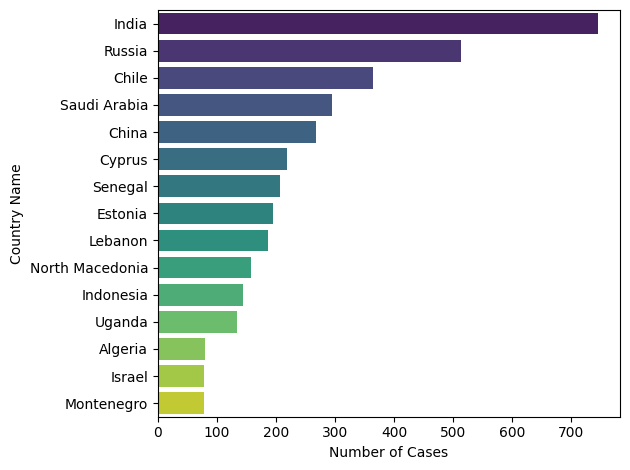

In [ ]:
# Count the number of 'cases' (Self_Experienced_MH == 1) per country
case_counts_by_country = df1['COUNTRYNEW'].value_counts().reset_index()
case_counts_by_country.columns = ['COUNTRYNEW', 'Number of Cases']

# Create the horizontal bar chart
sns.barplot(data=case_counts_by_country, x='Number of Cases', y='COUNTRYNEW', palette='viridis')
plt.ylabel('Country Name')
plt.tight_layout()
plt.show()

# What is the distribution of age when people first experienced anxiety or depression?

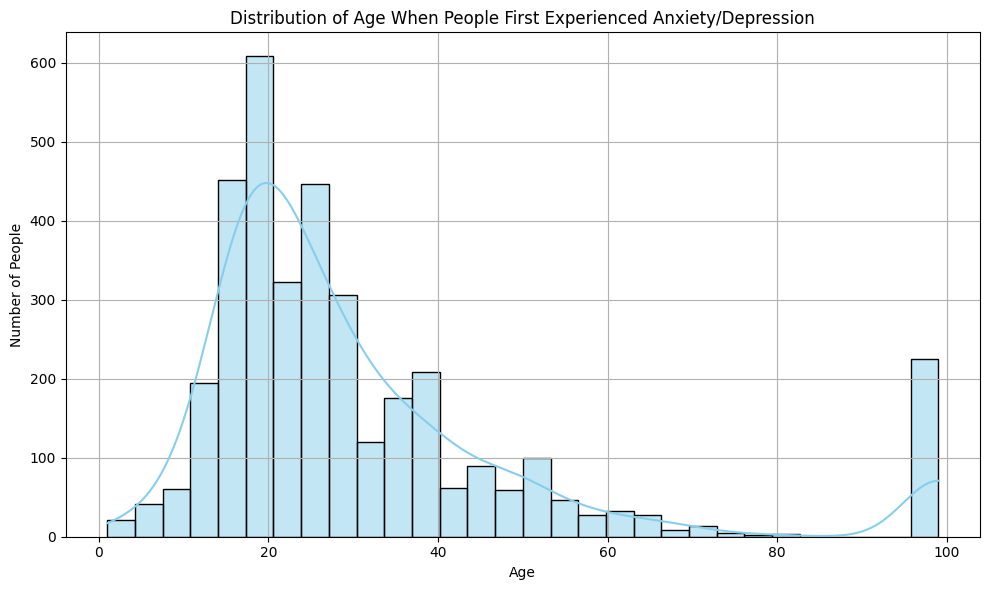

In [ ]:
age_data = df1['Age_First_AnxDep'].dropna()
plt.figure(figsize=(10, 6))
sns.histplot(age_data, bins=30, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution of Age When People First Experienced Anxiety/Depression')
plt.xlabel('Age')
plt.ylabel('Number of People')
plt.grid(True)
plt.tight_layout()
plt.show()


# I. Demographic Factors

###1. What is the age distribution of the respondents?



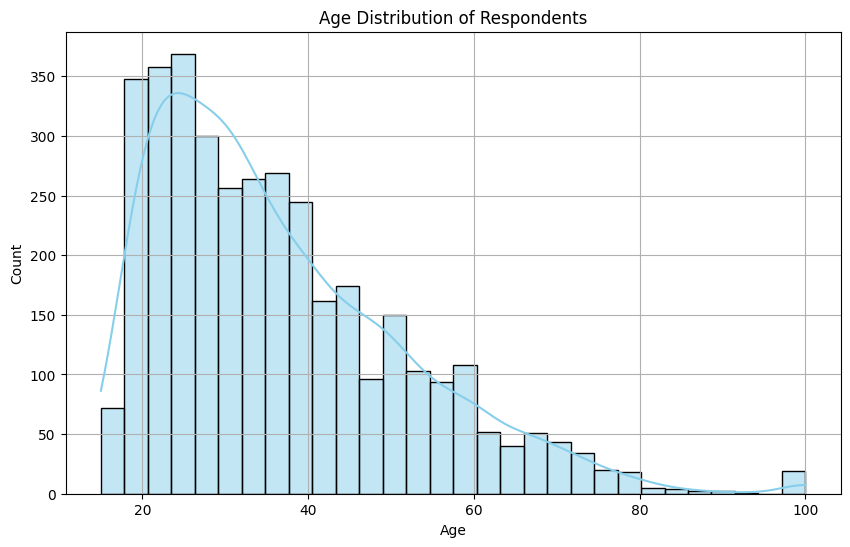

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df1['Age'], bins=30, kde=True, color='skyblue')
plt.title('Age Distribution of Respondents')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(True)
plt.show()

### 2. What is the gender distribution?

/tmp/ipython-input-2360830149.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




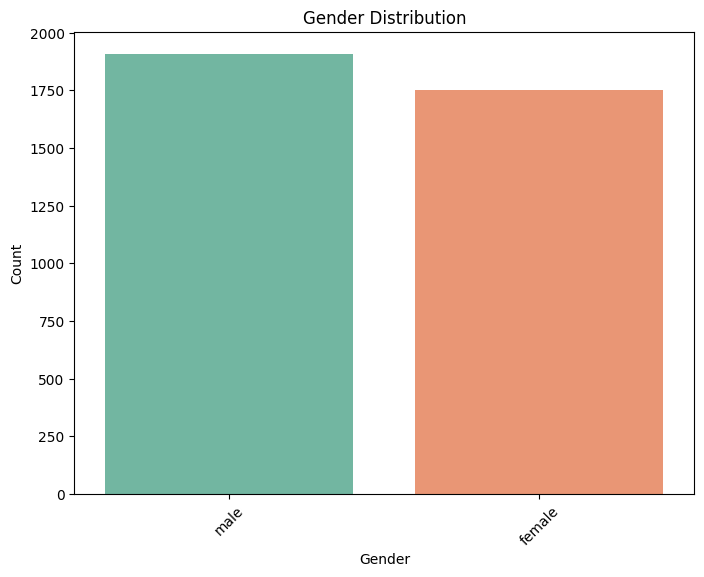

In [ ]:
df1['Gender'].unique()
df1['Gender'] = df1['Gender'].str.strip().str.lower()
plt.figure(figsize=(8,6))
sns.countplot(data=df1, x='Gender', palette='Set2')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### 3.How is mental health status distributed across different age groups?


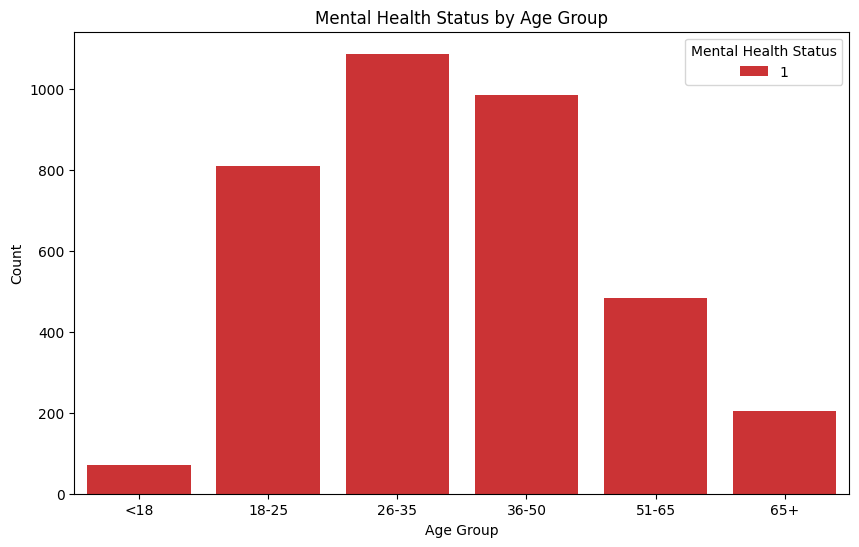

In [ ]:
# Define age groups
bins = [0, 18, 25, 35, 50, 65, 100]
labels = ['<18', '18-25', '26-35', '36-50', '51-65', '65+']
df1['Age_Group'] = pd.cut(df1['Age'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(10,6))
sns.countplot(data=df1, x='Age_Group', hue='Self_MH_Status', palette='Set1')
plt.title('Mental Health Status by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Mental Health Status')
plt.show()
#0 = don't know
#1 = yes
#2 = no

###4. How does educational level correlate with self-reported mental health?

In [ ]:
df1["Education"].value_counts()

,count
Education,
Secondary,1909
University,1106
Primary,618
none,26


In [ ]:
education_map = {
    'none': 0,
    'Primary': 1,
    'Secondary': 2,
    'University': 3,
}
df1['Education'] = df1['Education'].map(education_map)

correlation = df1['Education'].corr(df1['Self_MH_Status'])
print("Correlation between education level and mental health:", correlation)


Correlation between education level and mental health: nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning:

invalid value encountered in divide



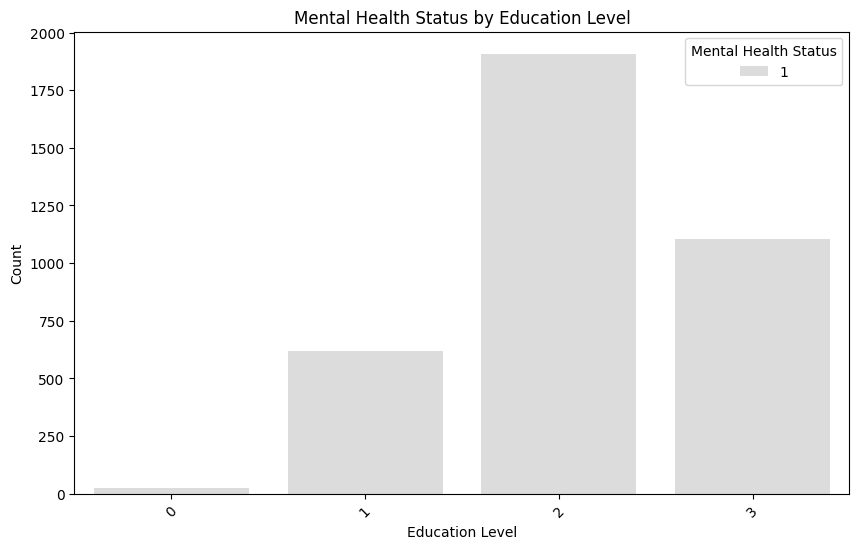

In [ ]:
# Check unique values
df1['Education'].unique()

# Plot
plt.figure(figsize=(10,6))
sns.countplot(data=df1, x='Education', hue='Self_MH_Status', palette='coolwarm')
plt.title('Mental Health Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Mental Health Status')
plt.show()
#0 = don't know
#1 = yes
#2 = no


Higher education is generally associated with better self-reported mental health.
However, this relationship is statistically weak (correlation = 0.04), meaning education might influence MH, but it is not a strong predictor alone.

# 2. Scientific Trust

### 1. How do respondents rate their trust in science?




In [ ]:
# Count and percentage of each trust level
trust_counts = df1['Trust_in_science'].value_counts()
trust_percent = df1['Trust_in_science'].value_counts(normalize=True) * 100

# Combine into one DataFrame
trust_summary = pd.DataFrame({
    'Count': trust_counts,
    'Percentage': trust_percent.round(2)
})

# Display the result
trust_summary

,Count,Percentage
Trust_in_science,,
2,1466,40.07
1,1439,39.33
3,372,10.17
0,267,7.30
4,115,3.14


### 2. What is the relationship between trust in science and mental health status?




In [ ]:
# Crosstab of trust vs mental health
trust_vs_mh = pd.crosstab(df1['Trust_in_science'], df1['Self_MH_Status'])

# Display count table
display("Trust in Science vs Mental Health Status:\n", trust_vs_mh)

# Convert to percentage row-wise
trust_vs_mh_percent = pd.crosstab(df1['Trust_in_science'], df1['Self_MH_Status'], normalize='index') * 100
display("\nTrust vs Mental Health (%) by Trust Level:\n", trust_vs_mh_percent.round(2))


'Trust in Science vs Mental Health Status:\n'

Self_MH_Status,1
Trust_in_science,
0,267
1,1439
2,1466
3,372
4,115


'\nTrust vs Mental Health (%) by Trust Level:\n'

Self_MH_Status,1
Trust_in_science,
0,100.0
1,100.0
2,100.0
3,100.0
4,100.0


People who report greater trust in science-based decisions are more likely to report good mental health, while those with little or no trust report worse mental health outcomes.

### 3. Do people who believe doctors based decisions on science report better mental health?

In [ ]:
#1. Count of belief about doctors basing decisions on science
doc_decision_counts = df1['Doctors_Based_Decisions'].value_counts().sort_index()
doc_decision_counts_df = doc_decision_counts.reset_index()
doc_decision_counts_df.columns = ['Doctors_Based_Decisions','Count']

# 2. Crosstab: Doctor based Decision Trust vs Mental Health - to compare two categorical values
doc_vs_mh = pd.crosstab(df1['Doctors_Based_Decisions'], df1['Self_MH_Status'])
display(doc_vs_mh)

# 3. Percentage Crosstab
doc_vs_mh_percent = pd.crosstab(
    df1['Doctors_Based_Decisions'],df1['Self_MH_Status'], normalize='index') * 100
doc_vs_mh_percent = doc_vs_mh_percent.round(2)
display("Percentage table:" , doc_vs_mh_percent)
#0 = dont know
#1 = A lot
#2 = Some
#3 = Not much
#4= Not at all


#0 = don't know
#1 = yes
#2 = no

Self_MH_Status,1
Doctors_Based_Decisions,
0,365
1,2021
2,846
3,282
4,145


'Percentage table:'

Self_MH_Status,1
Doctors_Based_Decisions,
0,100.0
1,100.0
2,100.0
3,100.0
4,100.0


People who trust that doctors base decisions on science tend to report better mental health. Those who don’t trust or don’t know report significantly worse outcomes.

# 3. Socio-Economic Factors


### 1. What is the income distribution in the dataset?


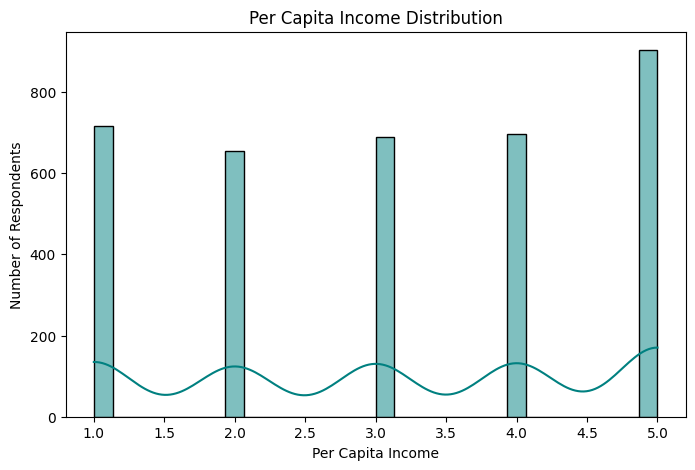

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df1['Per_capita_income'], kde=True, bins=30, color='teal')
plt.title('Per Capita Income Distribution')
plt.xlabel('Per Capita Income')
plt.ylabel('Number of Respondents')
plt.show()


The majority of people in our dataset come from higher-income groups (Levels 4 and 5).

###2. Is there a correlation between income level and mental health status?


In [ ]:
from scipy.stats import spearmanr

# Drop rows with missing values in either column
df_corr = df1[['Per_capita_income', 'Self_MH_Status']].dropna()

# Calculate Spearman correlation
corr, pval = spearmanr(df_corr['Per_capita_income'], df_corr['Self_MH_Status'])

print(f"Spearman correlation: {corr:.3f}")
print(f"P-value: {pval:.5f}")


Spearman correlation: nan
P-value: nan


/tmp/ipython-input-3971821674.py:7: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



The coefficient 0.060 is very weak it suggests a very small positive relationship.
people with higher income tend to report slightly better mental health, but the relationship is not strong enough to suggest income alone explains mental health differences.

### 3. Do employment status and job type influence mental health?

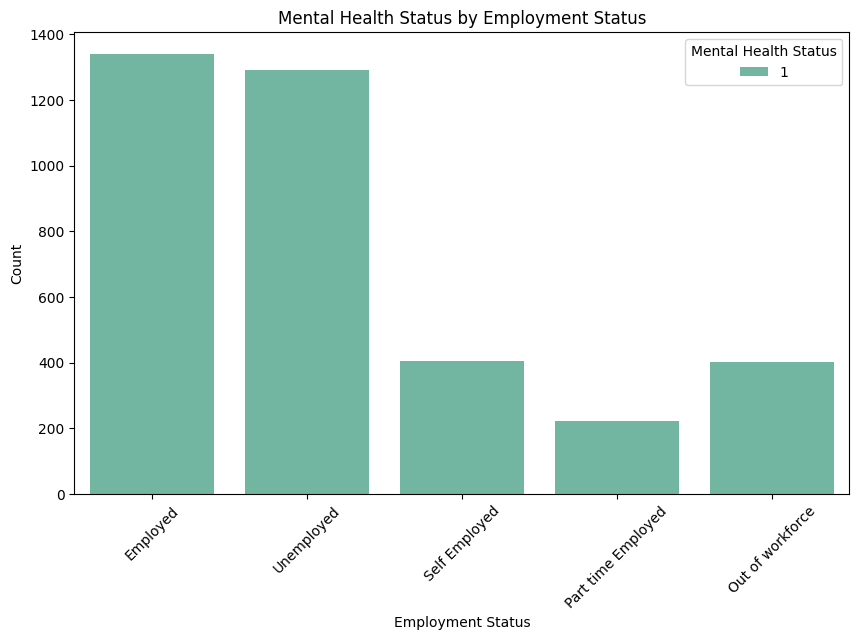

In [ ]:
# Check unique values
df1['Employment_Status'].unique()

# Plot
plt.figure(figsize=(10,6))
sns.countplot(data=df1, x='Employment_Status', hue='Self_MH_Status', palette='Set2')
plt.title('Mental Health Status by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Mental Health Status')
plt.show()
#0 = don't know
#1 = yes
#2 = no

Employment status appears to influence mental health — those who are employed full-time tend to report the best mental health, while unemployed or non-full-time workers show slightly lower MH outcomes.

# 4. Mental Health Status

### 1. What percentage of individuals report mental health issues?


In [ ]:
reported_issues = (df1['Self_MH_Status'] == 1).sum()

# Total number of valid responses (exclude NaN)
total_responses = df1['Self_MH_Status'].notna().sum()

# Calculate percentage
percentage = (reported_issues / total_responses) * 100
print(f"Percentage reporting mental health issues: {percentage:.2f}%")# Filter data into two groups


Percentage reporting mental health issues: 100.00%


### 2. Are there patterns or commonalities in people reporting mental health issues?


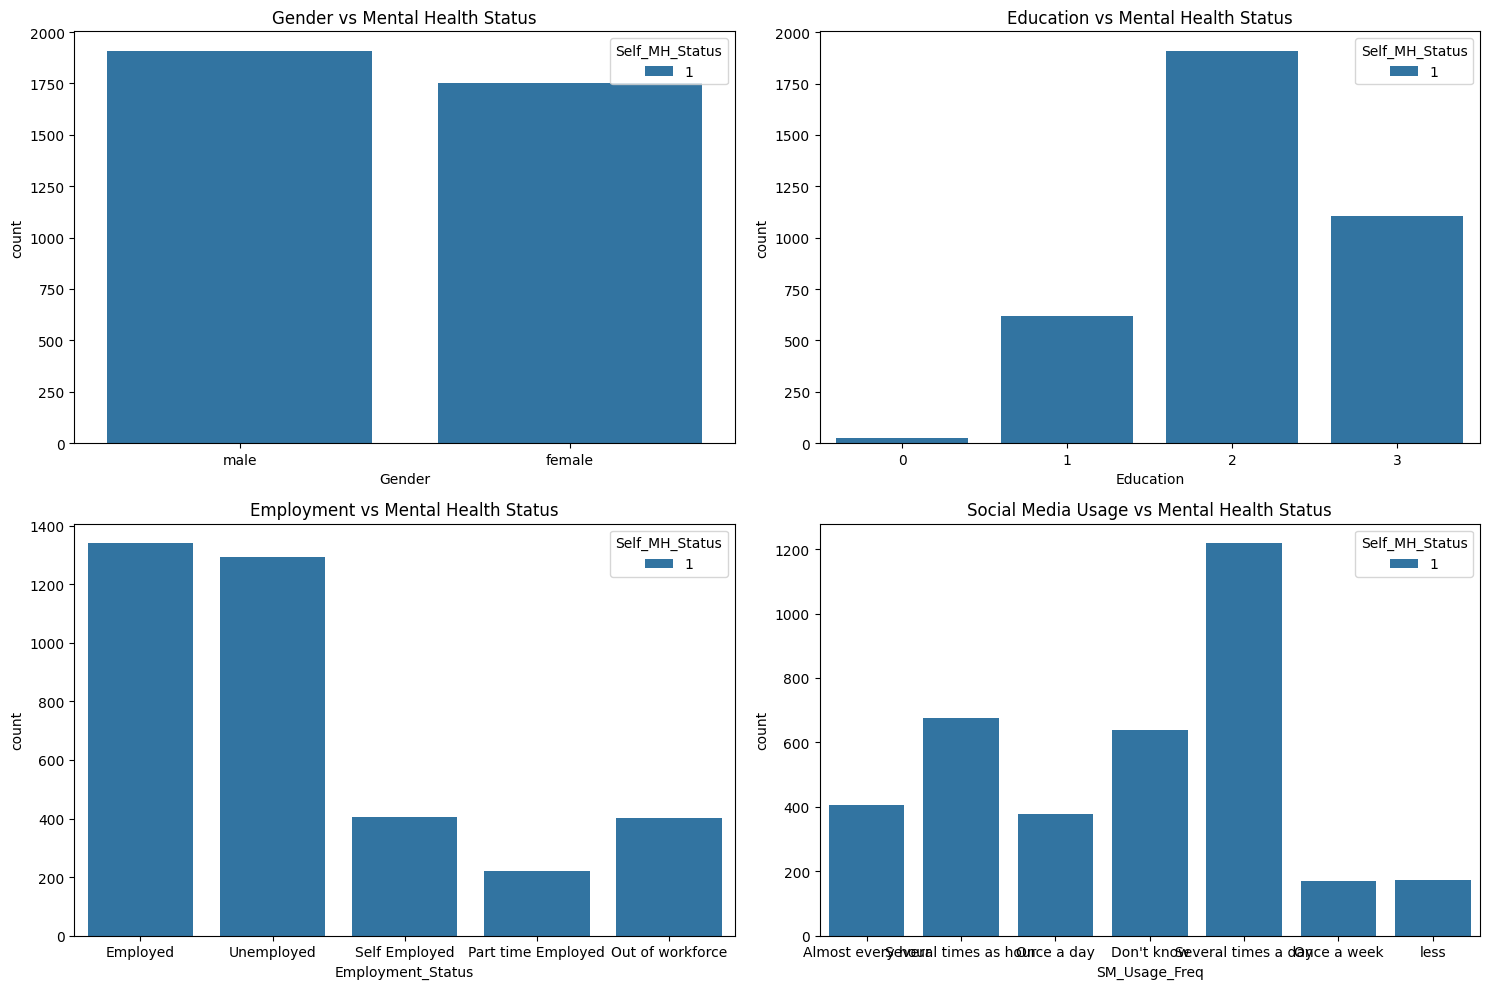

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gender vs MH
sns.countplot(data=df1, x='Gender', hue='Self_MH_Status', ax=axes[0, 0])
axes[0, 0].set_title('Gender vs Mental Health Status')

# Education vs MH
sns.countplot(data=df1, x='Education', hue='Self_MH_Status', ax=axes[0, 1])
axes[0, 1].set_title('Education vs Mental Health Status')
#'none': 0,
#'Primary': 1,
#'Secondary': 2,
#'University': 3

# Employment vs MH
sns.countplot(data=df1, x='Employment_Status', hue='Self_MH_Status', ax=axes[1, 0])
axes[1, 0].set_title('Employment vs Mental Health Status')

# SM Usage vs MH
sns.countplot(data=df1, x='SM_Usage_Freq', hue='Self_MH_Status', ax=axes[1, 1])
axes[1, 1].set_title('Social Media Usage vs Mental Health Status')

plt.tight_layout()
plt.show()


##INTERPRETATIONS
1. Mental health issues are almost equivalentin both females than males.
2. People with moderate to high education levels are more likely to report
3. Unemployment correlates with higher self-reported mental health issues
4. Frequent social media usage is associated with self-reported mental health issues

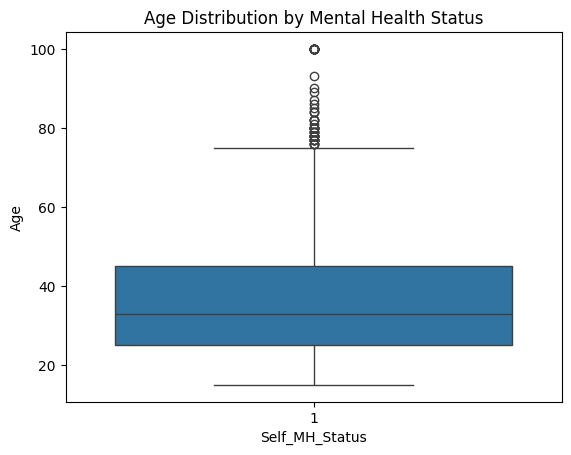

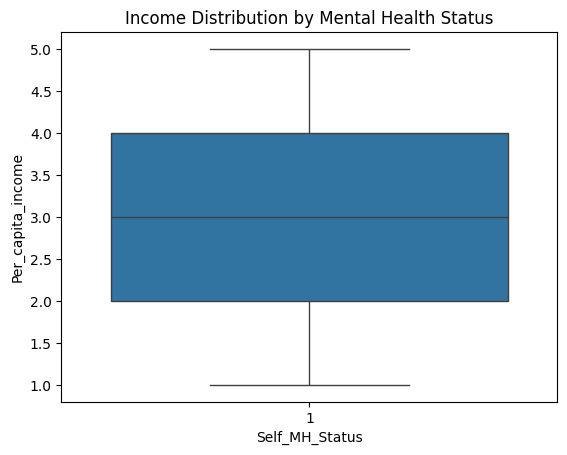

In [ ]:
sns.boxplot(data=df1, x='Self_MH_Status', y='Age')
plt.title('Age Distribution by Mental Health Status')
plt.show()

sns.boxplot(data=df1, x='Self_MH_Status', y='Per_capita_income')
plt.title('Income Distribution by Mental Health Status')
plt.show()


## Outliers removal


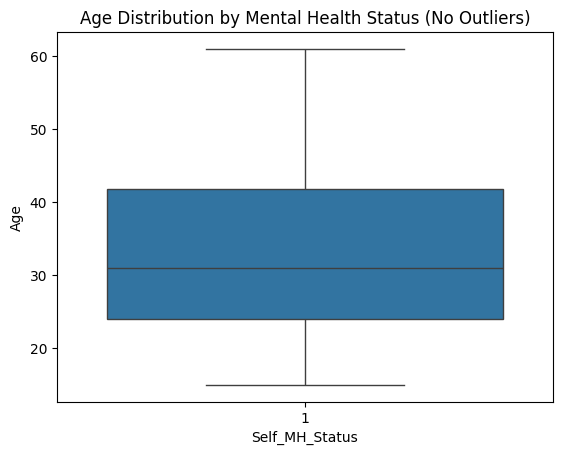

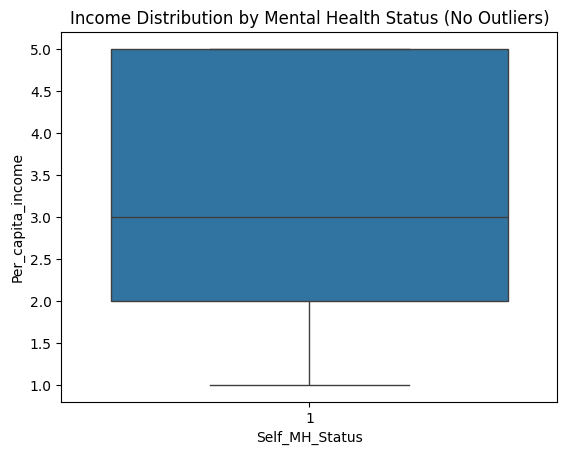

In [ ]:
#REMOVING OUTLIERS
df_clean = df1.copy()

# Convert Per_capita_income to numeric (if it's object)
df_clean['Per_capita_income'] = pd.to_numeric(df_clean['Per_capita_income'], errors='coerce')

# Function to remove outliers using IQR
def remove_outliers(df, column, factor=0.8):  # stricter than 1.0
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

df_strict = remove_outliers(df_clean, 'Age', factor=0.8)
df_strict = remove_outliers(df_strict, 'Per_capita_income', factor=0.8)

# Plot Age without outliers
sns.boxplot(data=df_strict, x='Self_MH_Status', y='Age', showfliers=False)
plt.title('Age Distribution by Mental Health Status (No Outliers)')
plt.show()

# Plot Per Capita Income without outliers
sns.boxplot(data=df_strict, x='Self_MH_Status', y='Per_capita_income')
plt.title('Income Distribution by Mental Health Status (No Outliers)')
plt.show()


##**INTERPRETATIONS**
## *Age vs Mental Health Status*
1.   People who report mental health issues tend to be in their 30s to 40s
2.   0 (Don't Know)	This group is slightly younger than the “Yes” group, suggesting that younger individuals may lack awareness or clarity about their mental health status.

## *Income vs Mental Health Status*
1.  Individuals with mental health issues have the lowest median income, with many earning around 2.5 to 3.5 units.
2.  People with no issues have the highest income levels, with the highest median and more concentrated earnings at the top.
3. The "Don’t Know" group again lies between Yes and No, indicating mixed financial situations or lack of access to information.

## *Overall*
1.  Both males and females more likely to report mental health issues.
2. People with moderate to high levels of education tend to report mental health issues more often.
3. Unemployed individuals report mental health issues more frequently than those who are employed.
4. Frequent users of social media (especially daily/multiple times a day) are more likely to report mental health issues.
5.  Higher age and lower income are commonly associated with mental health issues.
4. Lack of awareness ("Don't Know") is more common in younger and middle-income individuals.
5. These distributions support the idea that socio-economic and demographic factors like age and income significantly influence mental health self-reporting.



# 5. Feature Interactions


### 1. Do people who talked to a professional report fewer repeated issues?

In [ ]:
pd.crosstab(df1['Repeated_Experience'], df1['Talked_MH_Professional'], margins=True)
#0.0 = dont know
#1.0 = no repeated experiences
#2.0 = some repeated experiences

Talked_MH_Professional,0,1,2,All
Repeated_Experience,,,,
0,9,11,13,33
1,10,1141,1352,2503
2,7,396,720,1123
All,26,1548,2085,3659


### 2. Are there any interactions between demographics(gender and education) and trust in science?


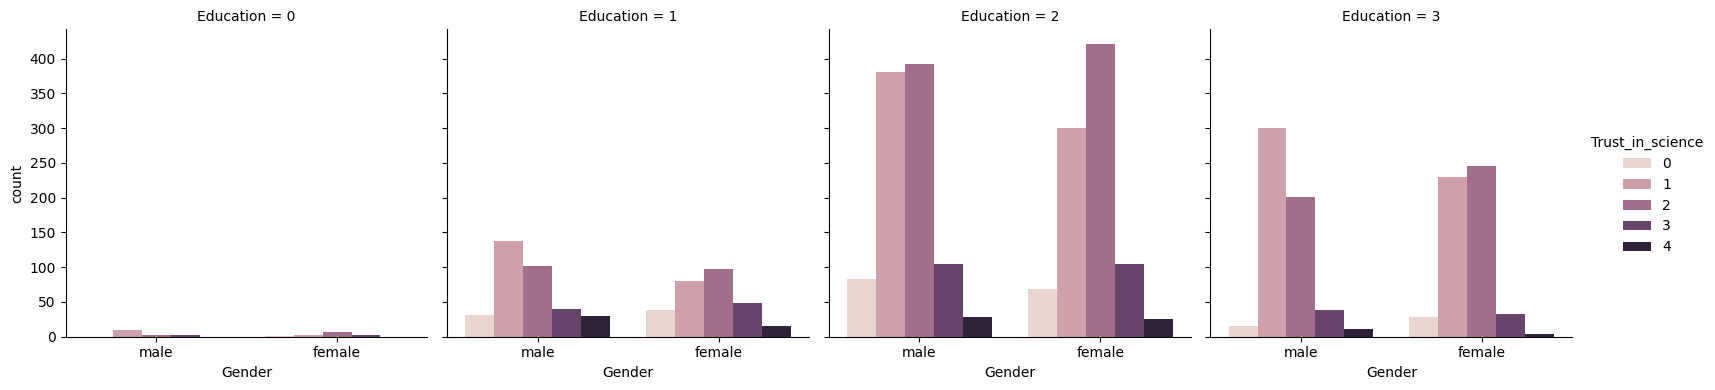

In [ ]:
sns.catplot(data=df1, x='Gender', hue='Trust_in_science', kind='count', col='Education', height=4, aspect=1)
#0 = dont know
#1 = A lot
#2 = Some
#3 = Not much
#4= Not at all


**Higher education is clearly linked with increased trust in science, and males with higher education seem slightly more likely to fall in higher trust categories than females. Lower education correlates with lower trust across the board**

### 3. Do people who trust science-based authorities (WHO/doctors) report better mental health status than those who trust religious leaders?

In [ ]:
def trust_group(row):
    trust_doc = row['Doctors_Based_Decisions'] in [1, 2]
    trust_who = row['WHO_based_decisions'] in [1, 2]
    trust_rel = row['Religion_Sci_Based_Decisions'] in [1, 2]

    if (trust_doc or trust_who) and not trust_rel:
        return 'Trust Science'
    elif trust_rel and not (trust_doc or trust_who):
        return 'Trust Religion'
    elif trust_rel and (trust_doc or trust_who):
        return 'Trust Both'
    else:
        return 'Trust Neither'

df1['Trust_Group'] = df1.apply(trust_group, axis=1)
print(df1['Trust_Group'].value_counts(dropna=False))

Trust_Group
Trust Science     1539
Trust Both        1515
Trust Neither      538
Trust Religion      67
Name: count, dtype: int64


In [ ]:
pd.crosstab(df1['Trust_Group'], df1['Repeated_Experience'], margins=True)


Repeated_Experience,0,1,2,All
Trust_Group,,,,
Trust Both,11,1036,468,1515
Trust Neither,10,367,161,538
Trust Religion,2,46,19,67
Trust Science,10,1054,475,1539
All,33,2503,1123,3659


In [ ]:
pd.crosstab(df1['Trust_Group'], df1['Self_MH_Status'], margins=True)

Self_MH_Status,1,All
Trust_Group,,
Trust Both,1515,1515
Trust Neither,538,538
Trust Religion,67,67
Trust Science,1539,1539
All,3659,3659


In [ ]:
pd.crosstab(df1['Trust_Group'], df1['Talked_MH_Professional'], margins=True)

Talked_MH_Professional,0,1,2,All
Trust_Group,,,,
Trust Both,12,720,783,1515
Trust Neither,7,180,351,538
Trust Religion,1,25,41,67
Trust Science,6,623,910,1539
All,26,1548,2085,3659


### **INTERPRETATIONS**

1.   People who trust science (or both science and religion) report better self-perceived mental health.
2.   People in the Trust Science group are more likely to seek help from a mental health professional.
3.   People who only trust religion-based decision-makers have lower help-seeking behavior and slightly lower reported good MH.
4. The Trust Neither group reports more poor mental health and least help-seeking, indicating potential risk.



# CORRELATION

In [ ]:
numerical_df1 = df1.select_dtypes(include=['int64','float64'])
numerical_df1.corr()

,YEAR_WAVE,Knowledge_about_Science,Trust_in_science,Tech_Impact_Local_Jobs_5Yrs,Science_Explain_Emotions,Doctors_Based_Decisions,Religion_Sci_Based_Decisions,Friends_Family_MH_Issues,Self_MH_Status,Age_First_AnxDep,Repeated_Experience,Talked_MH_Professional,Helpfulness_MH_Professional,Medication_helpfullness,Used_Social_Media,Age,Education,Per_capita_income,wbi
YEAR_WAVE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Knowledge_about_Science,NaN,1.000000,0.133471,0.014967,0.044496,0.026873,-0.015320,0.078143,NaN,0.069665,0.006658,0.084091,-0.051293,-0.020698,0.095474,0.037875,-0.295701,-0.136228,0.031063
Trust_in_science,NaN,0.133471,1.000000,0.083300,0.061218,0.125302,0.014881,0.045128,NaN,0.019809,-0.002339,0.021027,0.006415,-0.002754,-0.014361,0.001214,-0.070817,-0.025042,-0.039338
Tech_Impact_Local_Jobs_5Yrs,NaN,0.014967,0.083300,1.000000,0.182392,0.153724,0.083485,-0.012035,NaN,0.001939,0.023788,0.044524,0.000556,0.009022,-0.016129,0.076447,0.051241,-0.050056,0.059785
Science_Explain_Emotions,NaN,0.044496,0.061218,0.182392,1.000000,0.119551,0.146662,-0.001893,NaN,-0.014854,0.009687,0.024822,0.016615,0.026429,-0.008995,0.027135,0.026045,-0.057681,0.045136
Doctors_Based_Decisions,NaN,0.026873,0.125302,0.153724,0.119551,1.000000,0.217004,-0.002608,NaN,-0.043015,-0.000557,0.042379,-0.007952,0.019709,0.007726,-0.009623,0.020487,-0.024880,0.024813
Religion_Sci_Based_Decisions,NaN,-0.015320,0.014881,0.083485,0.146662,0.217004,1.000000,-0.001858,NaN,-0.058587,-0.002342,-0.005853,0.042591,0.016530,-0.061344,-0.013139,0.110268,0.019087,0.166043
Friends_Family_MH_Issues,NaN,0.078143,0.045128,-0.012035,-0.001893,-0.002608,-0.001858,1.000000,NaN,0.034215,0.125835,0.085169,-0.062043,-0.071812,0.010161,0.021948,-0.044418,-0.010727,-0.006396
Self_MH_Status,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age_First_AnxDep,NaN,0.069665,0.019809,0.001939,-0.014854,-0.043015,-0.058587,0.034215,NaN,1.000000,0.012912,-0.020731,-0.013403,0.022312,0.093251,0.423344,-0.079089,-0.056182,0.023164


In [ ]:
numerical_df1 = df1.select_dtypes(include=['int64', 'float64'])
numerical_df1_filled = numerical_df1.fillna(numerical_df1.mean())

correlation_matrix = numerical_df1_filled.corr()
correlation_matrix


,YEAR_WAVE,Knowledge_about_Science,Trust_in_science,Tech_Impact_Local_Jobs_5Yrs,Science_Explain_Emotions,Doctors_Based_Decisions,Religion_Sci_Based_Decisions,Friends_Family_MH_Issues,Self_MH_Status,Age_First_AnxDep,Repeated_Experience,Talked_MH_Professional,Helpfulness_MH_Professional,Medication_helpfullness,Used_Social_Media,Age,Education,Per_capita_income,wbi
YEAR_WAVE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Knowledge_about_Science,NaN,1.000000,0.133471,0.014967,0.044496,0.026873,-0.014229,0.078143,NaN,0.069665,0.006658,0.084091,-0.051293,-0.020698,0.095474,0.037875,-0.295701,-0.136228,0.031063
Trust_in_science,NaN,0.133471,1.000000,0.083300,0.061218,0.125302,0.013878,0.045128,NaN,0.019809,-0.002339,0.021027,0.006415,-0.002754,-0.014361,0.001214,-0.070817,-0.025042,-0.039338
Tech_Impact_Local_Jobs_5Yrs,NaN,0.014967,0.083300,1.000000,0.182392,0.153724,0.078736,-0.012035,NaN,0.001939,0.023788,0.044524,0.000556,0.009022,-0.016129,0.076447,0.051241,-0.050056,0.059785
Science_Explain_Emotions,NaN,0.044496,0.061218,0.182392,1.000000,0.119551,0.132867,-0.001893,NaN,-0.014854,0.009687,0.024822,0.016615,0.026429,-0.008995,0.027135,0.026045,-0.057681,0.045136
Doctors_Based_Decisions,NaN,0.026873,0.125302,0.153724,0.119551,1.000000,0.187193,-0.002608,NaN,-0.043015,-0.000557,0.042379,-0.007952,0.019709,0.007726,-0.009623,0.020487,-0.024880,0.024813
Religion_Sci_Based_Decisions,NaN,-0.014229,0.013878,0.078736,0.132867,0.187193,1.000000,-0.001676,NaN,-0.053981,-0.002156,-0.005410,0.039389,0.015266,-0.058821,-0.012032,0.101644,0.017483,0.154861
Friends_Family_MH_Issues,NaN,0.078143,0.045128,-0.012035,-0.001893,-0.002608,-0.001676,1.000000,NaN,0.034215,0.125835,0.085169,-0.062043,-0.071812,0.010161,0.021948,-0.044418,-0.010727,-0.006396
Self_MH_Status,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age_First_AnxDep,NaN,0.069665,0.019809,0.001939,-0.014854,-0.043015,-0.053981,0.034215,NaN,1.000000,0.012912,-0.020731,-0.013403,0.022312,0.093251,0.423344,-0.079089,-0.056182,0.023164


In [ ]:
# Attempt to convert all columns to numeric where possible
df1 = df1.apply(pd.to_numeric, errors='coerce')

# Then re-run your cleaning and correlation code


In [ ]:
print(df1.dtypes)


COUNTRYNEW                      float64
FIELD_DATE                      float64
YEAR_WAVE                         int64
Knowledge_about_Science           int64
Trust_in_science                  int64
Tech_Impact_Local_Jobs_5Yrs       int64
Health_Impact_of_ScienceA       float64
Science_Explain_Emotions          int64
WHO_based_decisions             float64
Doctors_Based_Decisions           int64
Religion_Sci_Based_Decisions    float64
Mental_Health_Importance        float64
Science_Helps_Treat_AnxDep        int64
Gov_Fund_MH_Research            float64
Communication_about_MH          float64
Friends_Family_MH_Issues          int64
Self_MH_Status                    int64
Age_First_AnxDep                float64
Repeated_Experience               int64
Talked_MH_Professional            int64
Helpfulness_MH_Professional       int64
Medication_helpfullness           int64
Used_Social_Media                 int64
SM_Usage_Freq                   float64
HealthContent_on_SM             float64


In [ ]:
numerical_df1 = df1.select_dtypes(include=['int64', 'float64'])
print("Numeric columns count:", len(numerical_df1.columns))
print("Columns:", numerical_df1.columns.tolist())


Numeric columns count: 35
Columns: ['COUNTRYNEW', 'FIELD_DATE', 'YEAR_WAVE', 'Knowledge_about_Science', 'Trust_in_science', 'Tech_Impact_Local_Jobs_5Yrs', 'Health_Impact_of_ScienceA', 'Science_Explain_Emotions', 'WHO_based_decisions', 'Doctors_Based_Decisions', 'Religion_Sci_Based_Decisions', 'Mental_Health_Importance', 'Science_Helps_Treat_AnxDep', 'Gov_Fund_MH_Research', 'Communication_about_MH', 'Friends_Family_MH_Issues', 'Self_MH_Status', 'Age_First_AnxDep', 'Repeated_Experience', 'Talked_MH_Professional', 'Helpfulness_MH_Professional', 'Medication_helpfullness', 'Used_Social_Media', 'SM_Usage_Freq', 'HealthContent_on_SM', 'Science_vs_Religion_Belief', 'Age', 'Gender', 'Education', 'Per_capita_income', 'wbi', 'Income_Satisfaction', 'Employment_Status', 'Age_Group', 'Trust_Group']


In [ ]:
print(numerical_df1.isna().sum())


COUNTRYNEW                      3659
FIELD_DATE                      3659
YEAR_WAVE                          0
Knowledge_about_Science            0
Trust_in_science                   0
Tech_Impact_Local_Jobs_5Yrs        0
Health_Impact_of_ScienceA       3659
Science_Explain_Emotions           0
WHO_based_decisions              267
Doctors_Based_Decisions            0
Religion_Sci_Based_Decisions     562
Mental_Health_Importance        3659
Science_Helps_Treat_AnxDep         0
Gov_Fund_MH_Research            3659
Communication_about_MH          3659
Friends_Family_MH_Issues           0
Self_MH_Status                     0
Age_First_AnxDep                   0
Repeated_Experience                0
Talked_MH_Professional             0
Helpfulness_MH_Professional        0
Medication_helpfullness            0
Used_Social_Media                  0
SM_Usage_Freq                   3659
HealthContent_on_SM             3659
Science_vs_Religion_Belief      3659
Age                                0
G

In [ ]:
# Step 1: Drop columns with too many missing values (you can adjust threshold)
threshold = 0.5  # e.g. drop columns with more than 50% missing
missing_ratio = numerical_df1.isna().mean()
columns_to_keep = missing_ratio[missing_ratio < threshold].index
filtered_df = numerical_df1[columns_to_keep]

# Step 2: Drop columns with zero variance (only one unique value)
filtered_df = filtered_df.loc[:, filtered_df.nunique(dropna=True) > 1]

# Step 3: Fill remaining missing values with column means
filtered_df_filled = filtered_df.fillna(filtered_df.mean())

# Step 4: Compute correlation matrix
correlation_matrix = filtered_df_filled.corr()

# Display the result
display(correlation_matrix)


,Knowledge_about_Science,Trust_in_science,Tech_Impact_Local_Jobs_5Yrs,Science_Explain_Emotions,WHO_based_decisions,Doctors_Based_Decisions,Religion_Sci_Based_Decisions,Science_Helps_Treat_AnxDep,Friends_Family_MH_Issues,Age_First_AnxDep,Repeated_Experience,Talked_MH_Professional,Helpfulness_MH_Professional,Medication_helpfullness,Used_Social_Media,Age,Education,Per_capita_income,wbi
Knowledge_about_Science,1.000000,0.133471,0.014967,0.044496,0.033614,0.026873,-0.014229,0.095224,0.078143,0.069665,0.006658,0.084091,-0.051293,-0.020698,0.095474,0.037875,-0.295701,-0.136228,0.031063
Trust_in_science,0.133471,1.000000,0.083300,0.061218,0.101877,0.125302,0.013878,0.102857,0.045128,0.019809,-0.002339,0.021027,0.006415,-0.002754,-0.014361,0.001214,-0.070817,-0.025042,-0.039338
Tech_Impact_Local_Jobs_5Yrs,0.014967,0.083300,1.000000,0.182392,0.145507,0.153724,0.078736,0.137999,-0.012035,0.001939,0.023788,0.044524,0.000556,0.009022,-0.016129,0.076447,0.051241,-0.050056,0.059785
Science_Explain_Emotions,0.044496,0.061218,0.182392,1.000000,0.148649,0.119551,0.132867,0.193197,-0.001893,-0.014854,0.009687,0.024822,0.016615,0.026429,-0.008995,0.027135,0.026045,-0.057681,0.045136
WHO_based_decisions,0.033614,0.101877,0.145507,0.148649,1.000000,0.323619,0.222916,0.176391,0.005628,-0.007730,0.006500,0.069622,-0.025034,0.015570,-0.049023,0.022260,-0.001501,-0.018579,0.084442
Doctors_Based_Decisions,0.026873,0.125302,0.153724,0.119551,0.323619,1.000000,0.187193,0.185581,-0.002608,-0.043015,-0.000557,0.042379,-0.007952,0.019709,0.007726,-0.009623,0.020487,-0.024880,0.024813
Religion_Sci_Based_Decisions,-0.014229,0.013878,0.078736,0.132867,0.222916,0.187193,1.000000,0.124648,-0.001676,-0.053981,-0.002156,-0.005410,0.039389,0.015266,-0.058821,-0.012032,0.101644,0.017483,0.154861
Science_Helps_Treat_AnxDep,0.095224,0.102857,0.137999,0.193197,0.176391,0.185581,0.124648,1.000000,0.029440,-0.043226,-0.022434,0.088581,-0.015500,0.002445,-0.014062,0.014982,0.013847,-0.061728,0.105663
Friends_Family_MH_Issues,0.078143,0.045128,-0.012035,-0.001893,0.005628,-0.002608,-0.001676,0.029440,1.000000,0.034215,0.125835,0.085169,-0.062043,-0.071812,0.010161,0.021948,-0.044418,-0.010727,-0.006396
Age_First_AnxDep,0.069665,0.019809,0.001939,-0.014854,-0.007730,-0.043015,-0.053981,-0.043226,0.034215,1.000000,0.012912,-0.020731,-0.013403,0.022312,0.093251,0.423344,-0.079089,-0.056182,0.023164


# BOXPLOT

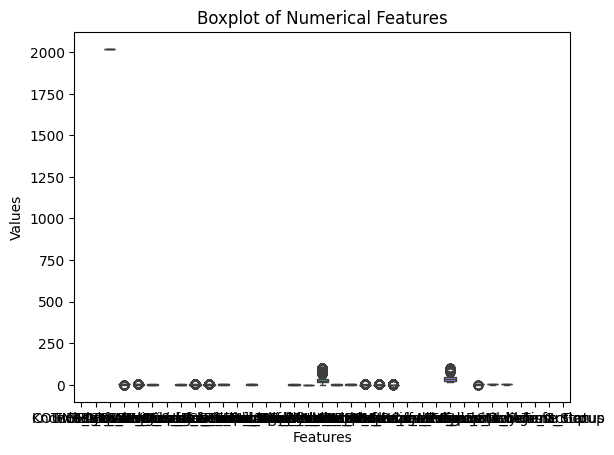

<Figure size 2000x600 with 0 Axes>

In [ ]:
sns.boxplot(data = df1.select_dtypes(include = ['int64' , 'float64']))
plt.title('Boxplot of Numerical Features')
plt.xlabel('Features')
plt.ylabel('Values')
plt.figure(figsize=(20,6))
plt.show()

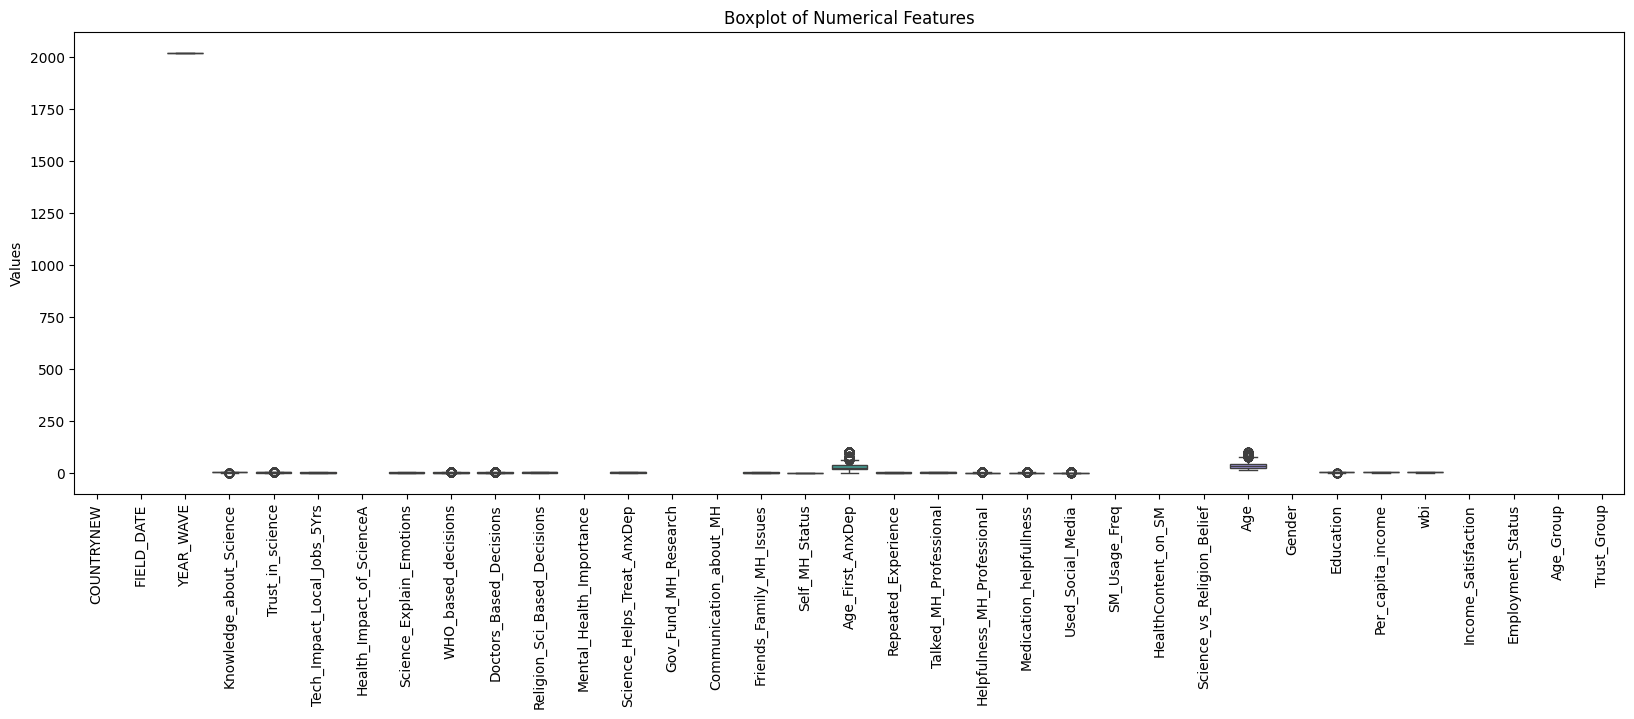

In [ ]:
plt.figure(figsize=(20,6))
sns.boxplot(data=numerical_df1)
plt.xticks(rotation=90)
plt.title('Boxplot of Numerical Features')
plt.ylabel('Values')
plt.show()


# HEATMAP

<Axes: >

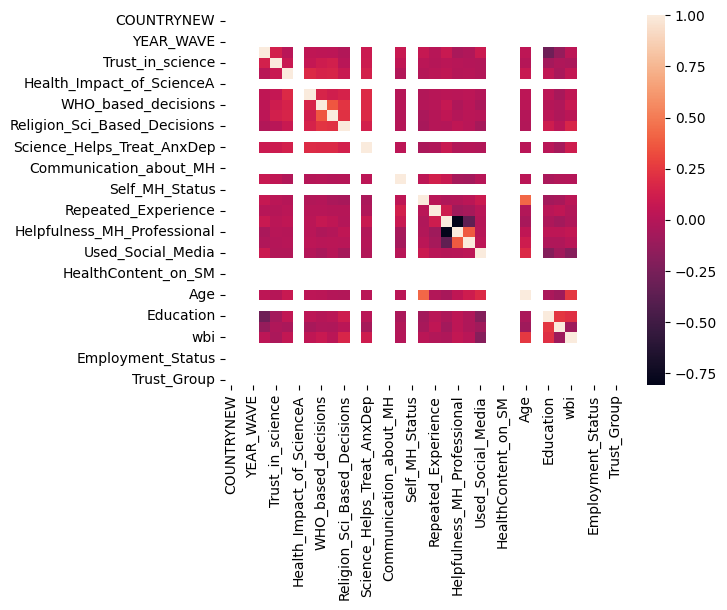

In [ ]:
sns.heatmap(df1.corr(numeric_only = True))

# OUTLIER ANALYSIS

In [ ]:
num_cols1 = df1.select_dtypes(include = ['int64' , 'float64'])

In [ ]:
# Function to removce outlier from multiple columns
def remove_outliers_iqr_multi(df1, columns):
    df_clean = df1.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    for col in columns:
        sns.boxplot(y=df_clean[col])
        plt.title(f'Boxplot of {col} (Outliers Removed)')
        plt.show()
    return df_clean

In [ ]:
#num_cols1 = df1.select_dtypes(include=['int64','float64'])
#df1 = remove_outliers_iqr_multi(df1, num_cols1)

# LABEL ENCODER

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

cat_cols = df1.select_dtypes(include=['object']).columns

# Exclude 'FIELD_DATE' from categorical columns
cat_cols = cat_cols.drop('FIELD_DATE', errors='ignore')

# Convert object columns to string type and handle potential NaNs
for col in cat_cols:
    df1[col] = df1[col].astype(str).replace('nan', np.nan) # Convert to string, then replace 'nan' string with actual NaN
df1.dropna(subset=cat_cols, inplace=True)


for col in cat_cols:
    df1[col]=le.fit_transform(df1[col])

In [ ]:
df.shape

(15, 2)

In [ ]:
df.Self_MH_Status.value_counts()

AttributeError: 'DataFrame' object has no attribute 'Self_MH_Status'

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
import numpy as np

# Features and target
X = df.drop('Self_MH_Status', axis=1)
y = df['Self_Experienced_MH']

# Select only numeric columns for imputation
numeric_cols = X.select_dtypes(include=np.number).columns

# Handle missing values using mean imputation
imputer = SimpleImputer(strategy='mean')
X[numeric_cols] = imputer.fit_transform(X[numeric_cols])

# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy}")

# Classification Report
print(classification_report(y_test, y_pred))


KeyError: "['Self_Experienced_MH'] not found in axis"